# A - 지사제 (로페라마이드) 관련 시각화

In [1]:
!apt-get -qq install fonts-nanum > /dev/null
!pip install matplotlib-venn -q
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib_venn import venn2
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.proportion import proportion_confint

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 및 로페라마이드 서브셋 추출
df = pd.read_csv('FDA_adverse_events_final.csv', low_memory=False)
lop_mask = df['suspect_drug'].str.contains('LOPERAMIDE', case=False, na=False)
lop, rest = df[lop_mask].copy(), df[~lop_mask].copy()
print(f'로페라마이드: {len(lop)}건 / 전체: {len(df)}건')

# 오남용/심혈관계 반응 키워드
abuse_kw = ['Drug abuse', 'Incorrect dose administered', 'Intentional overdose',
            'Drug withdrawal syndrome', 'Self-medication']
cardiac_kw = ['Cardiac arrest', 'Torsade de pointes', 'Ventricular tachycardia',
              'Electrocardiogram QT prolonged', 'Electrocardiogram QRS complex prolonged',
              'Arrhythmia', 'Cardiotoxicity', 'Syncope', 'Ventricular arrhythmia',
              'Sinus bradycardia', 'Bradycardia', 'Arteriosclerosis coronary artery']

reactions_str = lop['reactions'].fillna('')
lop['is_abuse'] = reactions_str.apply(lambda x: any(k.lower() in x.lower() for k in abuse_kw))
lop['is_cardiac'] = reactions_str.apply(lambda x: any(k.lower() in x.lower() for k in cardiac_kw))

로페라마이드: 397건 / 전체: 18273건


=== 위험도 통계검정 ===
serious              로페라마이드=57.4%  전체=86.2%  OR=0.22  p=3.908e-43
is_fatal             로페라마이드=7.8%  전체=14.6%  OR=0.50  p=6.489e-05
is_hospitalized      로페라마이드=29.0%  전체=34.5%  OR=0.77  p=0.02162
is_life_threat       로페라마이드=15.6%  전체=5.3%  OR=3.30  p=1.075e-13
is_disabling         로페라마이드=1.0%  전체=3.2%  OR=0.31  p=0.008371

신호탐지 결과: 65개 이상반응이 Evans criteria 충족
                      reaction  count_lop  count_rest        PRR        ROR       chi2             p
              Drug ineffective         56         965   2.613007   2.877900  54.181844  1.827678e-13
                    Drug abuse         52         115  20.360355  23.278437 651.610903 9.971767e-144
   Incorrect dose administered         40         171  10.532797  11.600898 275.020159  9.137429e-62
                 Off label use         32         493   2.922691   3.091256  37.255063  1.036456e-09
            Torsade de pointes         27           9 135.083123 144.867568 866.128937 2.265374e-190
Electrocardiogra

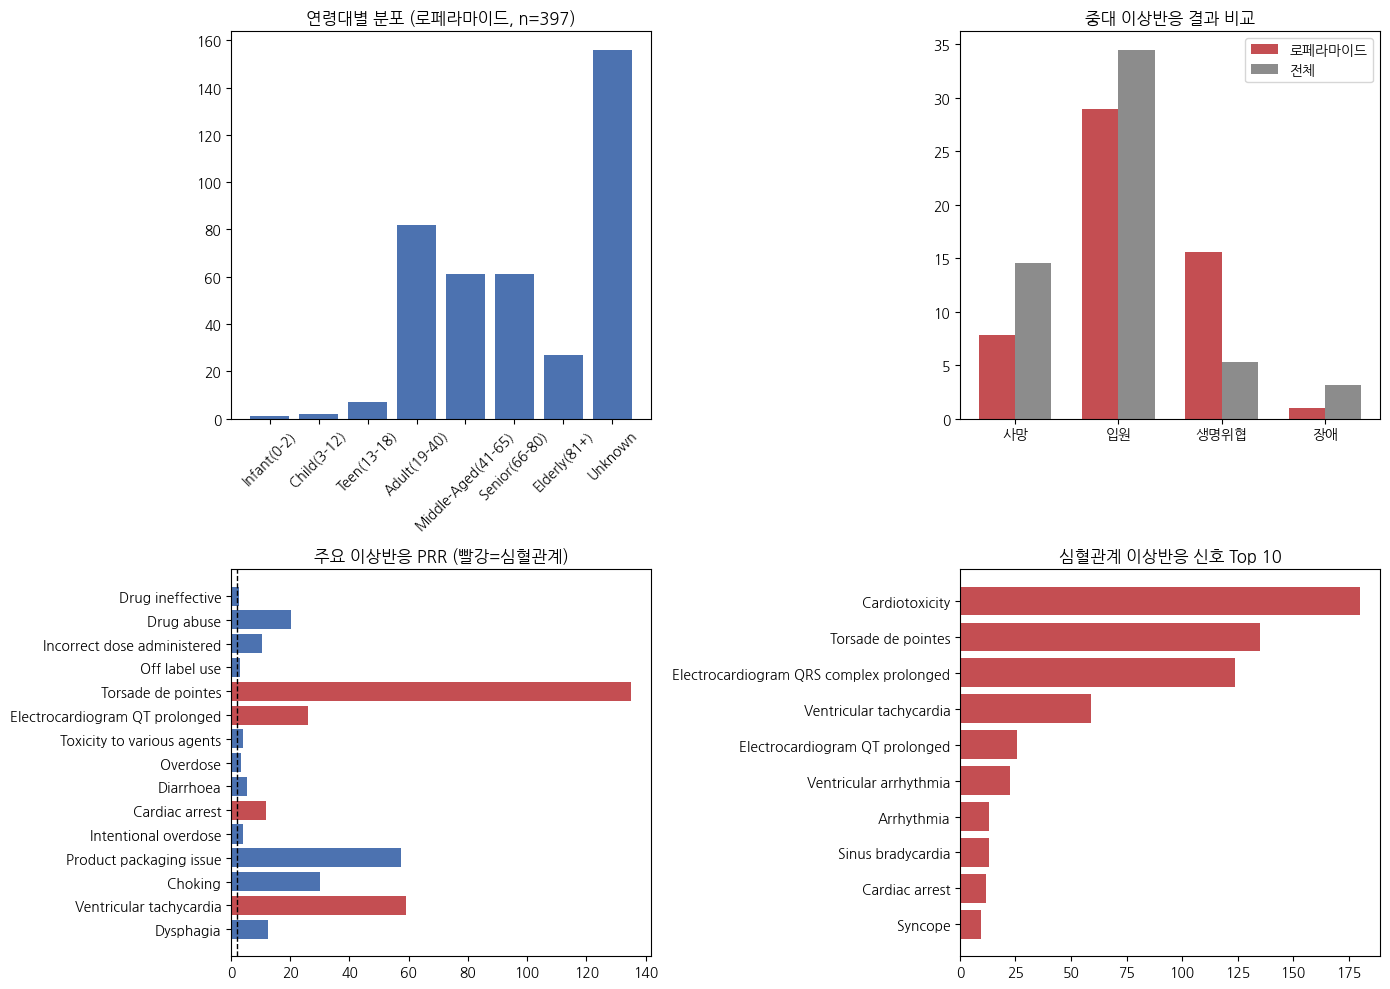

In [2]:
# 위험도 비교 (카이제곱/피셔) - 로페라마이드 vs 전체
print('=== 위험도 통계검정 ===')
for col in ['serious','is_fatal','is_hospitalized','is_life_threat','is_disabling']:
    if col == 'serious':
        a = (lop[col]=='Yes').sum(); c = (rest[col]=='Yes').sum()
    else:
        a = lop[col].sum(); c = rest[col].sum()
    b, d_ = len(lop)-a, len(rest)-c
    _, p = fisher_exact([[a,b],[c,d_]])
    odds = (a*d_)/(b*c) if b>0 and c>0 else np.nan
    print(f'{col:20s} 로페라마이드={a/(a+b)*100:.1f}%  전체={c/(c+d_)*100:.1f}%  OR={odds:.2f}  p={p:.4g}')

# 이상반응 신호탐지 (PRR/ROR, Evans criteria)
def explode_reactions(sub):
    return sub['reactions'].dropna().str.split(';').explode().str.strip()

lop_r, rest_r = explode_reactions(lop), explode_reactions(rest)
N_lop, N_rest = len(lop), len(rest)
lop_c, rest_c = lop_r.value_counts(), rest_r.value_counts()

rows = []
for reaction, a in lop_c.items():
    if a < 3:
        continue
    c = rest_c.get(reaction, 0)
    b, d_ = N_lop-a, N_rest-c
    prr = (a/(a+b))/(c/(c+d_)) if c>0 else np.inf
    ror = (a*d_)/(b*c) if c>0 and b>0 else np.inf
    chi2, p, _, _ = chi2_contingency([[a,b],[c,d_]], correction=True)
    rows.append((reaction, a, c, prr, ror, chi2, p))

res = pd.DataFrame(rows, columns=['reaction','count_lop','count_rest','PRR','ROR','chi2','p'])
signal = res[(res['PRR']>=2) & (res['chi2']>=4)].sort_values('count_lop', ascending=False)
print(f'\n신호탐지 결과: {len(signal)}개 이상반응이 Evans criteria 충족')
print(signal.head(15).to_string(index=False))

print(f'\n오남용 관련: {lop["is_abuse"].sum()}건 / 심혈관계: {lop["is_cardiac"].sum()}건 / 교집합: {(lop["is_abuse"]&lop["is_cardiac"]).sum()}건')

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14,10))

age_order = ['Infant(0-2)','Child(3-12)','Teen(13-18)','Adult(19-40)','Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)','Unknown']
ac = lop['age_group'].value_counts().reindex(age_order).fillna(0)
axes[0,0].bar(ac.index, ac.values, color='#4C72B0')
axes[0,0].set_title(f'연령대별 분포 (로페라마이드, n={len(lop)})')
axes[0,0].tick_params(axis='x', rotation=45)

outcomes = ['is_fatal','is_hospitalized','is_life_threat','is_disabling']
labels_kr = ['사망','입원','생명위협','장애']
x = np.arange(len(outcomes)); w = 0.35
axes[0,1].bar(x-w/2, [lop[c].mean()*100 for c in outcomes], w, label='로페라마이드', color='#C44E52')
axes[0,1].bar(x+w/2, [rest[c].mean()*100 for c in outcomes], w, label='전체', color='#8C8C8C')
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(labels_kr)
axes[0,1].set_title('중대 이상반응 결과 비교'); axes[0,1].legend()

top = signal.head(15)
colors = ['#C44E52' if any(k.lower() in r.lower() for k in cardiac_kw) else '#4C72B0' for r in top['reaction']]
axes[1,0].barh(top['reaction'][::-1], top['PRR'][::-1], color=colors[::-1])
axes[1,0].axvline(2, color='black', linestyle='--', linewidth=1)
axes[1,0].set_title('주요 이상반응 PRR (빨강=심혈관계)')

cardiac_signal = signal[signal['reaction'].apply(lambda x: any(k.lower() in x.lower() for k in cardiac_kw))].sort_values('PRR', ascending=False).head(10)
axes[1,1].barh(cardiac_signal['reaction'][::-1], cardiac_signal['PRR'][::-1], color='#C44E52')
axes[1,1].set_title('심혈관계 이상반응 신호 Top 10')

plt.tight_layout()
plt.show()

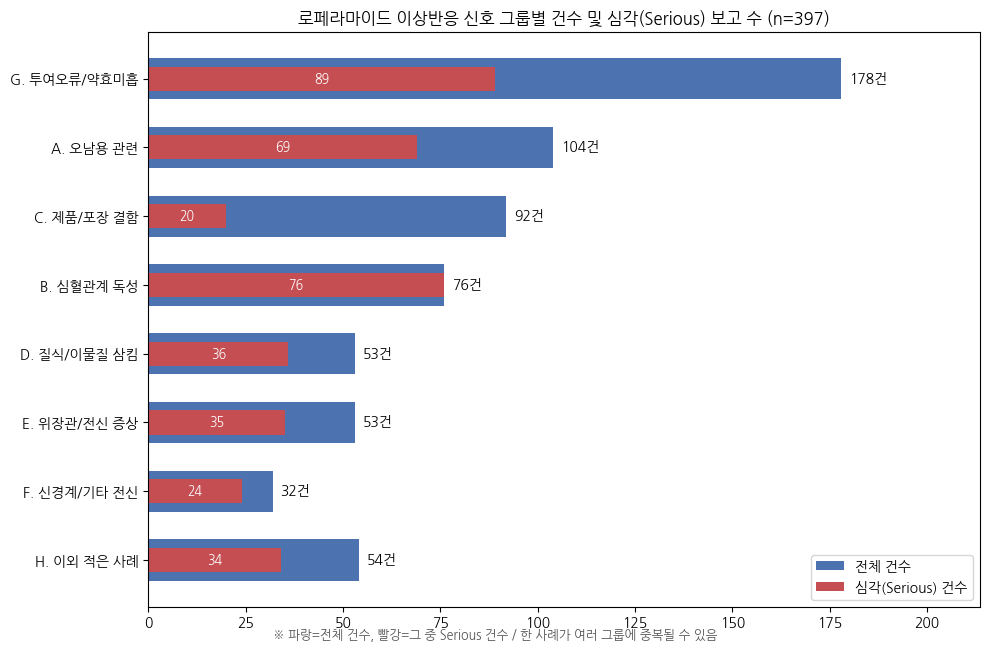

In [3]:
# 이상반응 신호를 7개 그룹으로 분류 (오남용/심혈관/포장결함/질식/위장관/신경계/투여오류)
group_map = {
    'A. 오남용 관련': ['Drug abuse', 'Incorrect dose administered', 'Intentional overdose',
                    'Drug withdrawal syndrome', 'Self-medication'],
    'B. 심혈관계 독성': cardiac_kw,
    'C. 제품/포장 결함': ['Product packaging issue', 'Product size issue', 'Product blister packaging issue',
                      'Product package associated injury', 'Product physical issue', 'Product label issue',
                      'Product packaging difficult to open', 'Product coating issue', 'Product quality issue',
                      'Product formulation issue', 'Product storage error', 'Product use complaint',
                      'Expired product administered'],
    'D. 질식/이물질 삼킴': ['Choking', 'Dysphagia', 'Foreign body', 'Foreign body in respiratory tract',
                       'Foreign body in throat', 'Aspiration', 'Retching', 'Throat irritation', 'Pain in jaw'],
    'E. 위장관/전신 증상': ['Diarrhoea', 'Constipation', 'Flatulence', 'Clostridium difficile colitis',
                       'Pancreatitis', 'Dysgeusia', 'Product taste abnormal', 'Decreased appetite'],
    'F. 신경계/기타 전신': ['Somnolence', 'Tremor', 'Muscle spasms', 'Aggression', 'Brain injury',
                       'Unresponsive to stimuli', 'Urinary retention'],
    'G. 투여오류/약효미흡': ['Drug ineffective', 'Off label use', 'Toxicity to various agents', 'Overdose',
                        'Product use in unapproved indication', 'Wrong technique in product usage process',
                        'Intentional product use issue', 'Incorrect product administration duration',
                        'Inappropriate schedule of drug administration', 'Therapeutic response delayed'],
}

counts, serious_counts, all_kws = {}, {}, []
for name, kws in group_map.items():
    flag = reactions_str.apply(lambda x: any(k.lower() in x.lower() for k in kws))
    counts[name] = flag.sum()
    serious_counts[name] = (lop.loc[flag, 'serious'] == 'Yes').sum()
    all_kws += kws

flagged_any = reactions_str.apply(lambda x: any(k.lower() in x.lower() for k in all_kws))
h_count = (~flagged_any).sum()
h_serious = (lop.loc[~flagged_any, 'serious'] == 'Yes').sum()

order = sorted(counts.items(), key=lambda x: x[1], reverse=True)
order.append(('H. 이외 적은 사례', h_count))

labels = [k for k, v in order]
values = [v for k, v in order]
serious_vals = [serious_counts.get(k, h_serious) for k in labels]
labels_r, values_r, serious_r = labels[::-1], values[::-1], serious_vals[::-1]
y_pos = range(len(labels_r))

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(y_pos, values_r, color='#4C72B0', height=0.6, label='전체 건수')
ax.barh(y_pos, serious_r, color='#C44E52', height=0.35, label='심각(Serious) 건수')

for y, (v, s) in enumerate(zip(values_r, serious_r)):
    ax.text(v + 2, y, f'{v}건', va='center', fontsize=10)
    ax.text(s / 2, y, f'{s}', va='center', ha='center', fontsize=9, color='white', fontweight='bold')

ax.set_yticks(y_pos); ax.set_yticklabels(labels_r)
ax.set_xlim(0, max(values) * 1.2)
ax.set_title(f'로페라마이드 이상반응 신호 그룹별 건수 및 심각(Serious) 보고 수 (n={len(lop)})')
ax.legend(loc='lower right')
fig.text(0.5, 0.01, '※ 파랑=전체 건수, 빨강=그 중 Serious 건수 / 한 사례가 여러 그룹에 중복될 수 있음',
          ha='center', fontsize=9, color='#555555')

plt.tight_layout()
plt.show()

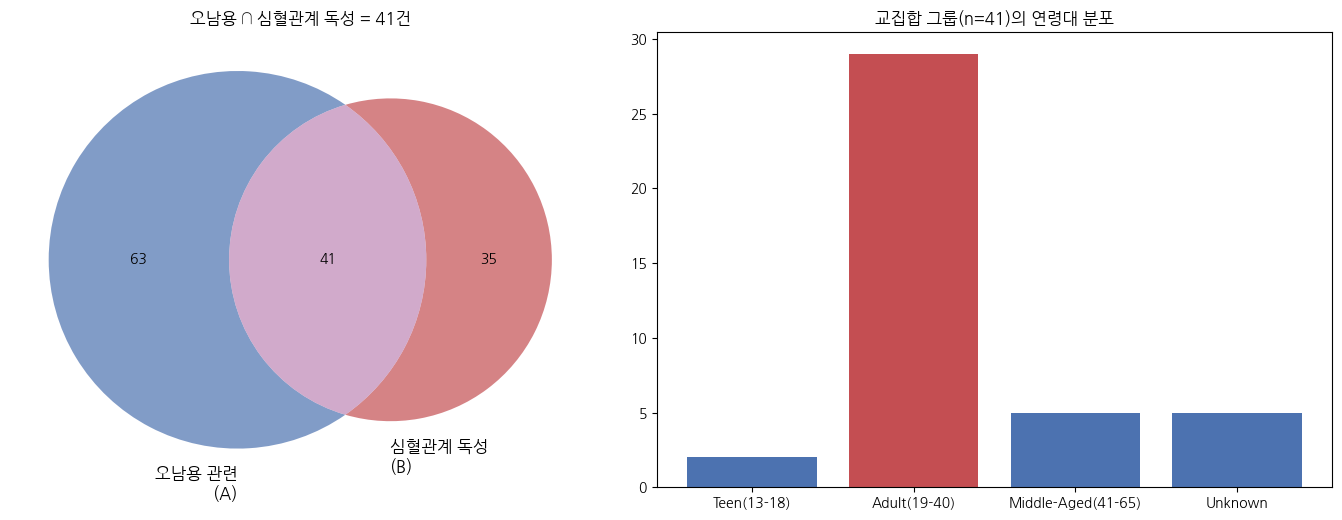

In [4]:
# 오남용 반응 ∩ 심혈관계 독성 반응 벤 다이어그램
overlap = lop[lop['is_abuse'] & lop['is_cardiac']]

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
n_abuse_only = lop['is_abuse'].sum() - len(overlap)
n_cardiac_only = lop['is_cardiac'].sum() - len(overlap)
venn2(subsets=(n_abuse_only, n_cardiac_only, len(overlap)),
      set_labels=('오남용 관련\n(A)', '심혈관계 독성\n(B)'), ax=ax1,
      set_colors=('#4C72B0', '#C44E52'), alpha=0.7)
ax1.set_title(f'오남용 ∩ 심혈관계 독성 = {len(overlap)}건')

ax2 = fig.add_subplot(gs[0, 1])
age_order_overlap = ['Teen(13-18)', 'Adult(19-40)', 'Middle-Aged(41-65)', 'Unknown']
ac = overlap['age_group'].value_counts().reindex(age_order_overlap).fillna(0)
colors_age = ['#4C72B0' if a != 'Adult(19-40)' else '#C44E52' for a in ac.index]
ax2.bar(ac.index, ac.values, color=colors_age)
ax2.set_title(f'교집합 그룹(n={len(overlap)})의 연령대 분포')

plt.tight_layout()
plt.show()

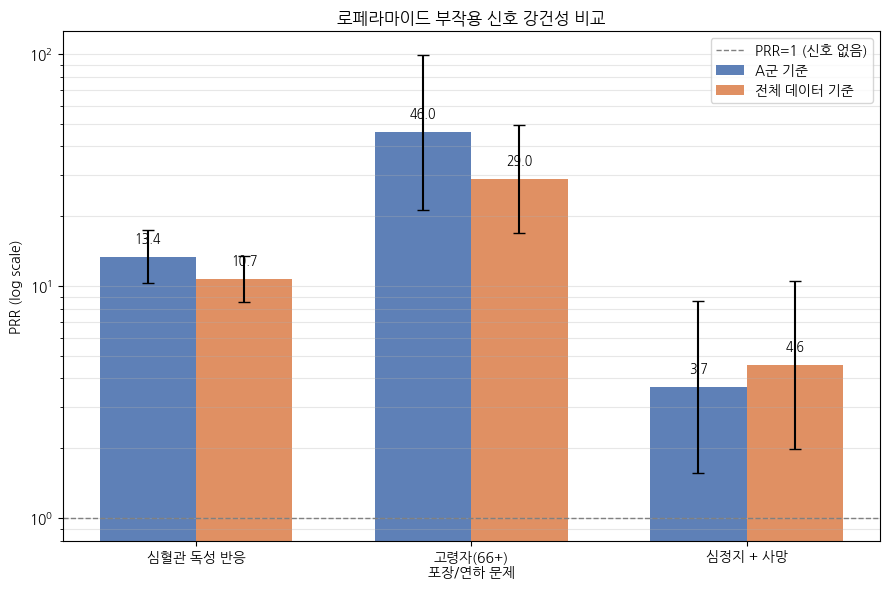

          category  baseline       PRR        lo        hi            p
         심혈관 독성 반응     A군 기준 13.378750 10.277225 17.416272 4.818362e-53
         심혈관 독성 반응 전체 데이터 기준 10.727604  8.527180 13.495845 3.975550e-50
고령자(66+)\n포장/연하 문제     A군 기준 46.045455 21.294541 99.564667 8.214030e-20
고령자(66+)\n포장/연하 문제 전체 데이터 기준 28.983471 16.988495 49.447675 1.753069e-19
          심정지 + 사망     A군 기준  3.668965  1.560127  8.628337 8.885693e-03
          심정지 + 사망 전체 데이터 기준  4.579089  1.988820 10.542964 2.840507e-03


In [5]:
# PRR 신호 강건성: A군(A그룹 다른 약물) 기준 vs 전체 데이터 기준 비교
pkg_kw = ['Product packaging issue', 'Choking', 'Dysphagia',
          'Product blister packaging issue', 'Product size issue', 'Product package associated injury']

def has_kw(series, kws):
    return series.fillna('').str.contains('|'.join(kws), case=False, regex=True)

df['cardiac'] = has_kw(df['reactions'], cardiac_kw)
df['pkg'] = has_kw(df['reactions'], pkg_kw)
df['cardiac_arrest_fatal'] = has_kw(df['reactions'], ['Cardiac arrest']) & (df['is_fatal'] == True)
df['is_elderly'] = df['age_group'].isin(['Senior(66-80)', 'Elderly(81+)'])
df['is_A'] = df['WHO_ATC'] == 'A'

def rr_ci(a, n1, c, n2):
    r1, r2 = a / n1, c / n2
    rr = r1 / r2
    se = np.sqrt(1/a - 1/n1 + 1/c - 1/n2)
    lo, hi = np.exp(np.log(rr) - 1.96*se), np.exp(np.log(rr) + 1.96*se)
    _, p = fisher_exact([[a, n1-a], [c, n2-c]])
    return rr, lo, hi, p

rest_A = df[df['is_A'] & ~lop_mask]
lop_e = df[lop_mask & df['is_elderly']]
rest_A_e = df[df['is_A'] & ~lop_mask & df['is_elderly']]
rest_whole_e = df[~lop_mask & df['is_elderly']]

rows = []
for label, sub, base_A, base_whole, col in [
    ('심혈관 독성 반응', df[lop_mask], rest_A, df[~lop_mask], 'cardiac'),
    ('고령자(66+)\n포장/연하 문제', lop_e, rest_A_e, rest_whole_e, 'pkg'),
    ('심정지 + 사망', df[lop_mask], rest_A, df[~lop_mask], 'cardiac_arrest_fatal'),
]:
    a, n1 = sub[col].sum(), len(sub)
    for base_label, base in [('A군 기준', base_A), ('전체 데이터 기준', base_whole)]:
        c, n2 = base[col].sum(), len(base)
        rr, lo, hi, p = rr_ci(a, n1, c, n2)
        rows.append({'category': label, 'baseline': base_label, 'PRR': rr, 'lo': lo, 'hi': hi, 'p': p})

res_prr = pd.DataFrame(rows)
categories = res_prr['category'].unique()
baselines = ['A군 기준', '전체 데이터 기준']
colors_base = {'A군 기준': '#4C72B0', '전체 데이터 기준': '#DD8452'}

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(categories)); width = 0.35

for i, base in enumerate(baselines):
    sub = res_prr[res_prr['baseline'] == base].set_index('category').loc[categories]
    offset = (i - 0.5) * width
    err = np.array([sub['PRR'] - sub['lo'], sub['hi'] - sub['PRR']])
    ax.bar(x + offset, sub['PRR'], width, yerr=err, capsize=4, label=base, color=colors_base[base], alpha=0.9)
    for xi, val in zip(x + offset, sub['PRR']):
        ax.text(xi, val * 1.15, f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')

ax.axhline(1, color='gray', linestyle='--', linewidth=1, label='PRR=1 (신호 없음)')
ax.set_yscale('log')
ax.set_ylabel('PRR (log scale)')
ax.set_title('로페라마이드 부작용 신호 강건성 비교')
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3, which='both')

plt.tight_layout()
plt.show()
print(res_prr.to_string(index=False))

/tmp/ipykernel_2519/2868910171.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  serious_n = lop.groupby('brand_type').apply(lambda x: (x['serious'] == 'Yes').sum()).reindex(order_brand)
/tmp/ipykernel_2519/2868910171.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nonserious_n = lop.groupby('brand_type').apply(lambda x: (x['serious'] != 'Yes').sum()).reindex(order_brand)


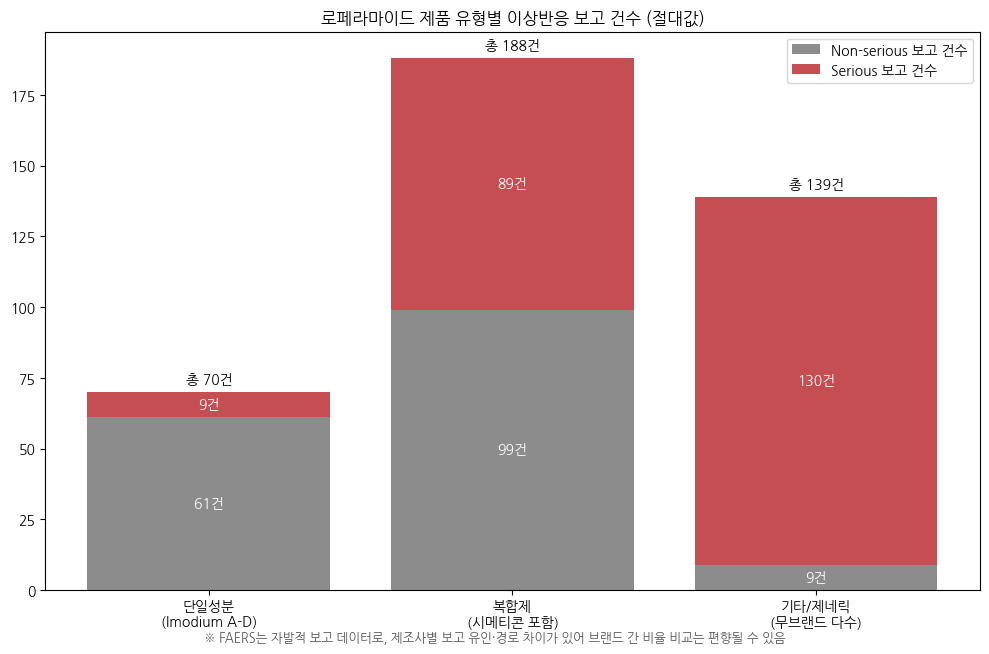

In [6]:
# 제품(브랜드) 유형별 이상반응 보고 건수 (단일성분/복합제/기타 제네릭)
def brand_type(b):
    b = str(b).upper()
    if 'MULTI-SYMPTOM' in b: return '복합제\n(시메티콘 포함)'
    if 'A-D' in b: return '단일성분\n(Imodium A-D)'
    return '기타/제네릭\n(무브랜드 다수)'

lop['brand_type'] = lop['brand_name'].fillna('Unknown').apply(brand_type)
order_brand = ['단일성분\n(Imodium A-D)', '복합제\n(시메티콘 포함)', '기타/제네릭\n(무브랜드 다수)']

serious_n = lop.groupby('brand_type').apply(lambda x: (x['serious'] == 'Yes').sum()).reindex(order_brand)
nonserious_n = lop.groupby('brand_type').apply(lambda x: (x['serious'] != 'Yes').sum()).reindex(order_brand)

fig, ax = plt.subplots(figsize=(10, 6.5))
x = np.arange(len(order_brand))
ax.bar(x, nonserious_n, color='#8C8C8C', label='Non-serious 보고 건수')
ax.bar(x, serious_n, bottom=nonserious_n, color='#C44E52', label='Serious 보고 건수')

for i, (sn, nn) in enumerate(zip(serious_n, nonserious_n)):
    total = sn + nn
    ax.text(i, nn/2, f'{nn}건', ha='center', va='center', fontsize=10, color='white')
    ax.text(i, nn + sn/2, f'{sn}건', ha='center', va='center', fontsize=10, color='white')
    ax.text(i, total + 3, f'총 {total}건', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(order_brand)
ax.set_title('로페라마이드 제품 유형별 이상반응 보고 건수 (절대값)')
ax.legend(loc='upper right')
fig.text(0.5, 0.005,
         '※ FAERS는 자발적 보고 데이터로, 제조사별 보고 유인·경로 차이가 있어 브랜드 간 비율 비교는 편향될 수 있음',
         ha='center', fontsize=9, color='#555555')

plt.tight_layout()
plt.show()

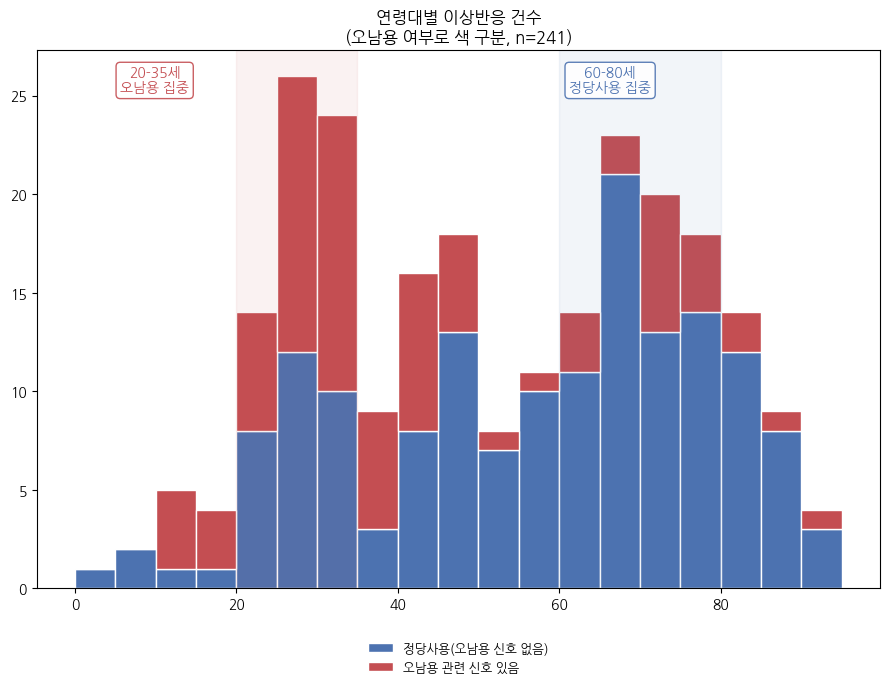

In [7]:
# 연령대별 오남용 신호 유무에 따른 이상반응 건수 분포
lop['age_num'] = pd.to_numeric(lop['patient_age_years'], errors='coerce')
age_data = lop.dropna(subset=['age_num'])
abuse_ages = age_data.loc[age_data['is_abuse'], 'age_num']
nonabuse_ages = age_data.loc[~age_data['is_abuse'], 'age_num']
bins = np.arange(0, 100, 5)

fig, ax = plt.subplots(figsize=(9, 7))
ax.hist([nonabuse_ages, abuse_ages], bins=bins, stacked=True,
        color=['#4C72B0', '#C44E52'],
        label=['정당사용(오남용 신호 없음)', '오남용 관련 신호 있음'], edgecolor='white')

ax.axvspan(20, 35, color='#C44E52', alpha=0.07)
ax.axvspan(60, 80, color='#4C72B0', alpha=0.07)
ax.text(0.14, 0.97, '20-35세\n오남용 집중', transform=ax.transAxes, ha='center', va='top',
        color='#C44E52', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='#C44E52', alpha=0.9))
ax.text(0.68, 0.97, '60-80세\n정당사용 집중', transform=ax.transAxes, ha='center', va='top',
        color='#4C72B0', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='#4C72B0', alpha=0.9))

ax.set_title(f'연령대별 이상반응 건수\n(오남용 여부로 색 구분, n={len(age_data)})')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.18), fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

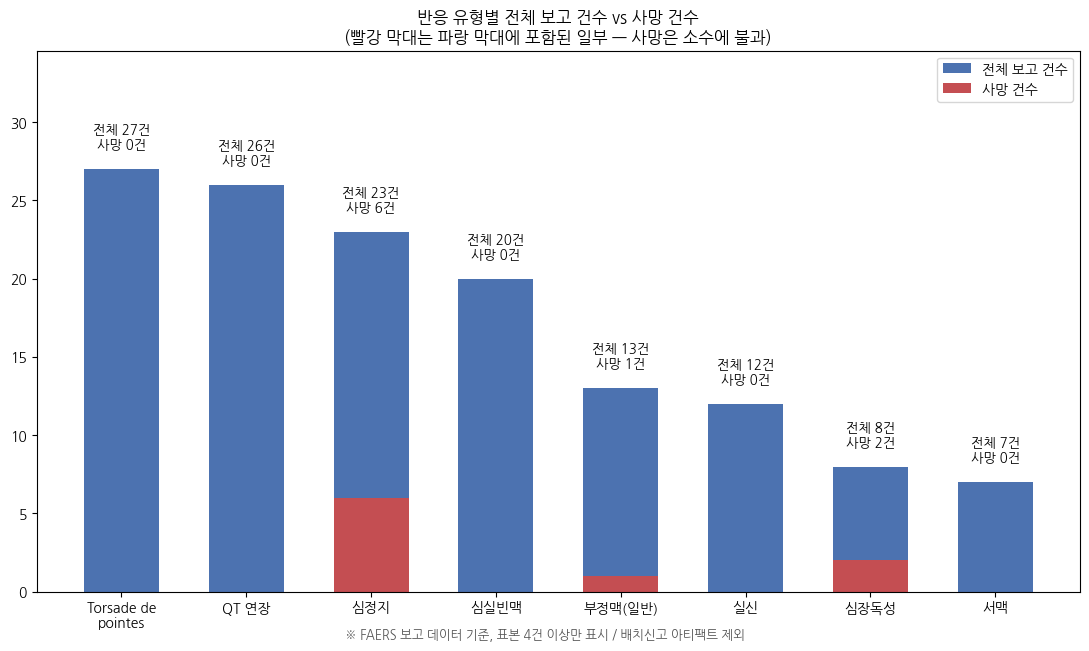

In [8]:
# 심혈관계 반응 유형별 전체 보고 건수 vs 사망 건수 (배치성 신고 제외)
lop['receive_date'] = pd.to_datetime(lop['receive_date'])
batch_dates = ['2022-12-09','2022-12-10','2022-12-12','2022-12-13',
               '2018-06-07','2018-06-08','2016-05-31']
lop_clean = lop[~lop['receive_date'].isin(pd.to_datetime(batch_dates))].copy()
cardiac_cases = lop_clean[lop_clean['is_cardiac']]

label_kr = {
    'Cardiac arrest': '심정지', 'Torsade de pointes': 'Torsade de\npointes',
    'Ventricular tachycardia': '심실빈맥', 'Electrocardiogram QT prolonged': 'QT 연장',
    'Arrhythmia': '부정맥(일반)', 'Cardiotoxicity': '심장독성',
    'Syncope': '실신', 'Bradycardia': '서맥',
}

rows = []
for r in cardiac_kw:
    if r not in label_kr:
        continue
    sub = cardiac_cases[cardiac_cases['reactions'].str.contains(r, case=False, na=False)]
    if len(sub) >= 4:
        rows.append((label_kr[r], len(sub), sub['is_fatal'].sum()))

res_cardiac = pd.DataFrame(rows, columns=['label', 'total', 'died']).sort_values('total', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6.5))
x = np.arange(len(res_cardiac))
ax.bar(x, res_cardiac['total'], color='#4C72B0', width=0.6, label='전체 보고 건수')
ax.bar(x, res_cardiac['died'], color='#C44E52', width=0.6, label='사망 건수')

for i, (t, d_) in enumerate(zip(res_cardiac['total'], res_cardiac['died'])):
    ax.text(i, t + 1.3, f'전체 {t}건\n사망 {d_}건', ha='center', fontsize=9.5)

ax.set_xticks(x); ax.set_xticklabels(res_cardiac['label'])
ax.set_ylim(0, res_cardiac['total'].max() * 1.28)
ax.set_title('반응 유형별 전체 보고 건수 vs 사망 건수\n(빨강 막대는 파랑 막대에 포함된 일부 — 사망은 소수에 불과)')
ax.legend(loc='upper right')
fig.text(0.5, 0.01, '※ FAERS 보고 데이터 기준, 표본 4건 이상만 표시 / 배치신고 아티팩트 제외',
          ha='center', fontsize=9, color='#555555')

plt.tight_layout()
plt.show()

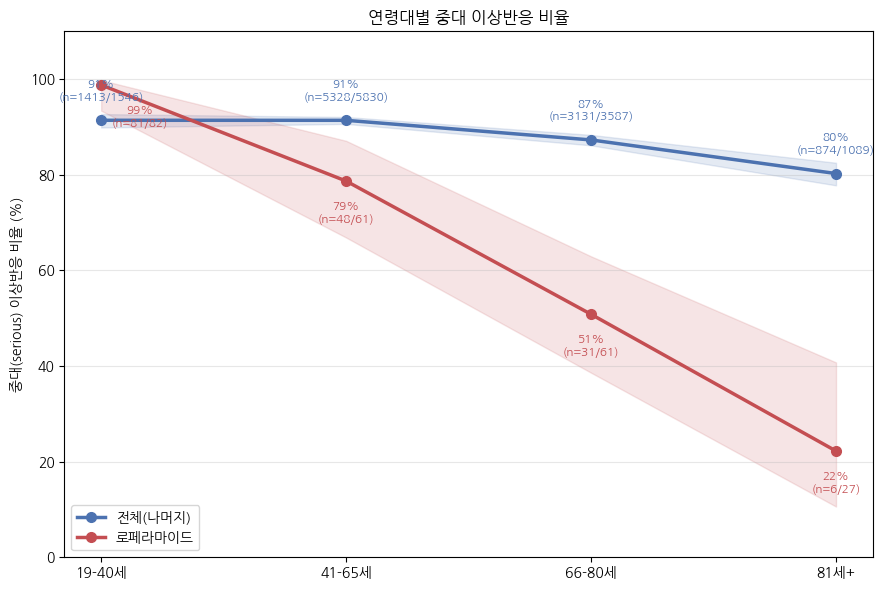

  group                age    n    k      rate        lo        hi
 로페라마이드       Adult(19-40)   82   81 98.780488 93.410660 99.784401
 로페라마이드 Middle-Aged(41-65)   61   48 78.688525 66.877585 87.100226
 로페라마이드      Senior(66-80)   61   31 50.819672 38.602618 62.939605
 로페라마이드       Elderly(81+)   27    6 22.222222 10.607239 40.756929
전체(나머지)       Adult(19-40) 1546 1413 91.397154 89.894760 92.694333
전체(나머지) Middle-Aged(41-65) 5830 5328 91.389365 90.641755 92.082467
전체(나머지)      Senior(66-80) 3587 3131 87.287427 86.157269 88.337805
전체(나머지)       Elderly(81+) 1089  874 80.257117 77.788339 82.513180


In [9]:
# 연령대별 중대 이상반응 비율 (Wilson 95% CI)
df['group'] = np.where(lop_mask, '로페라마이드', '전체(나머지)')
df['is_serious'] = df['serious'] == 'Yes'

age_order_adult = ['Adult(19-40)', 'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)']
age_labels_adult = ['19-40세', '41-65세', '66-80세', '81세+']

rows = []
for grp in ['로페라마이드', '전체(나머지)']:
    sub = df[df['group'] == grp]
    for age in age_order_adult:
        s = sub[sub['age_group'] == age]
        n = len(s)
        k = s['is_serious'].sum()
        lo, hi = proportion_confint(k, n, method='wilson')
        rows.append({'group': grp, 'age': age, 'n': n, 'k': k, 'rate': k/n*100, 'lo': lo*100, 'hi': hi*100})

res_age = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 6))
colors_grp = {'로페라마이드': '#C44E52', '전체(나머지)': '#4C72B0'}
x = np.arange(len(age_order_adult))

for grp in ['전체(나머지)', '로페라마이드']:
    sub = res_age[res_age['group'] == grp].set_index('age').loc[age_order_adult]
    ax.plot(x, sub['rate'], marker='o', linewidth=2.5, markersize=7, color=colors_grp[grp], label=grp)
    ax.fill_between(x, sub['lo'], sub['hi'], color=colors_grp[grp], alpha=0.15)
    for xi, row in zip(x, sub.itertuples()):
        dx = 28 if grp == '로페라마이드' and xi == 0 else 0
        dy = 14 if grp == '전체(나머지)' else -30
        ax.annotate(f'{row.rate:.0f}%\n(n={row.k}/{row.n})', (xi, row.rate), textcoords='offset points',
                    xytext=(dx, dy), ha='center', fontsize=8.5, color=colors_grp[grp], fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(age_labels_adult)
ax.set_ylabel('중대(serious) 이상반응 비율 (%)')
ax.set_ylim(0, 110)
ax.set_title('연령대별 중대 이상반응 비율')
ax.legend(loc='lower left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print(res_age.to_string(index=False))

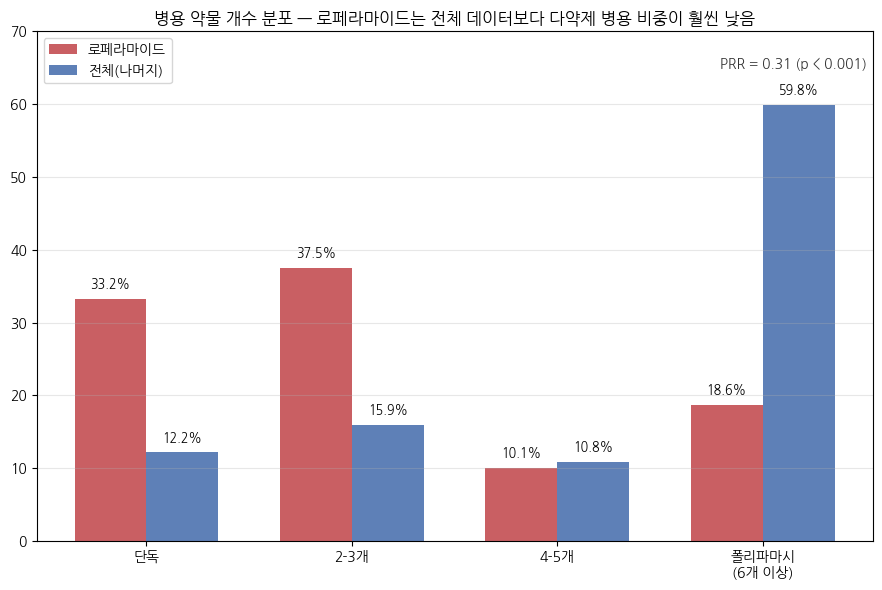

drug_count_category  Single  2-3 Drugs  4-5 Drugs  Polypharmacy(6+)
group                                                              
로페라마이드                 33.2       37.5       10.1              18.6
전체(나머지)                12.2       15.9       10.8              59.8

폴리파마시(6+) PRR = 0.311, p = 4.81e-62


In [10]:
# 병용 약물 개수 분포 비교 + 폴리파마시(6+) PRR
cat_order = ['Single', '2-3 Drugs', '4-5 Drugs', 'Polypharmacy(6+)']
cat_labels = ['단독', '2-3개', '4-5개', '폴리파마시\n(6개 이상)']

dist = pd.crosstab(df['group'], df['drug_count_category'], normalize='index')[cat_order] * 100

mask_poly = df['drug_count_category'] == 'Polypharmacy(6+)'
a, n1 = (lop_mask & mask_poly).sum(), lop_mask.sum()
c, n2 = (~lop_mask & mask_poly).sum(), (~lop_mask).sum()
prr = (a/n1) / (c/n2)
_, p = fisher_exact([[a, n1-a], [c, n2-c]])

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(cat_order)); width = 0.35

for i, grp in enumerate(['로페라마이드', '전체(나머지)']):
    offset = (i - 0.5) * width
    vals = dist.loc[grp, cat_order]
    ax.bar(x + offset, vals, width, label=grp, color=colors_grp[grp], alpha=0.9)
    for xi, v in zip(x + offset, vals):
        ax.text(xi, v + 1.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.annotate(f'PRR = {prr:.2f} (p < 0.001)', xy=(3.15, 65), ha='center', fontsize=10, fontweight='bold', color='#333')

ax.set_xticks(x); ax.set_xticklabels(cat_labels)
ax.set_ylim(0, 70)
ax.set_title('병용 약물 개수 분포 — 로페라마이드는 전체 데이터보다 다약제 병용 비중이 훨씬 낮음')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(dist.round(1))
print(f'\n폴리파마시(6+) PRR = {prr:.3f}, p = {p:.2e}')

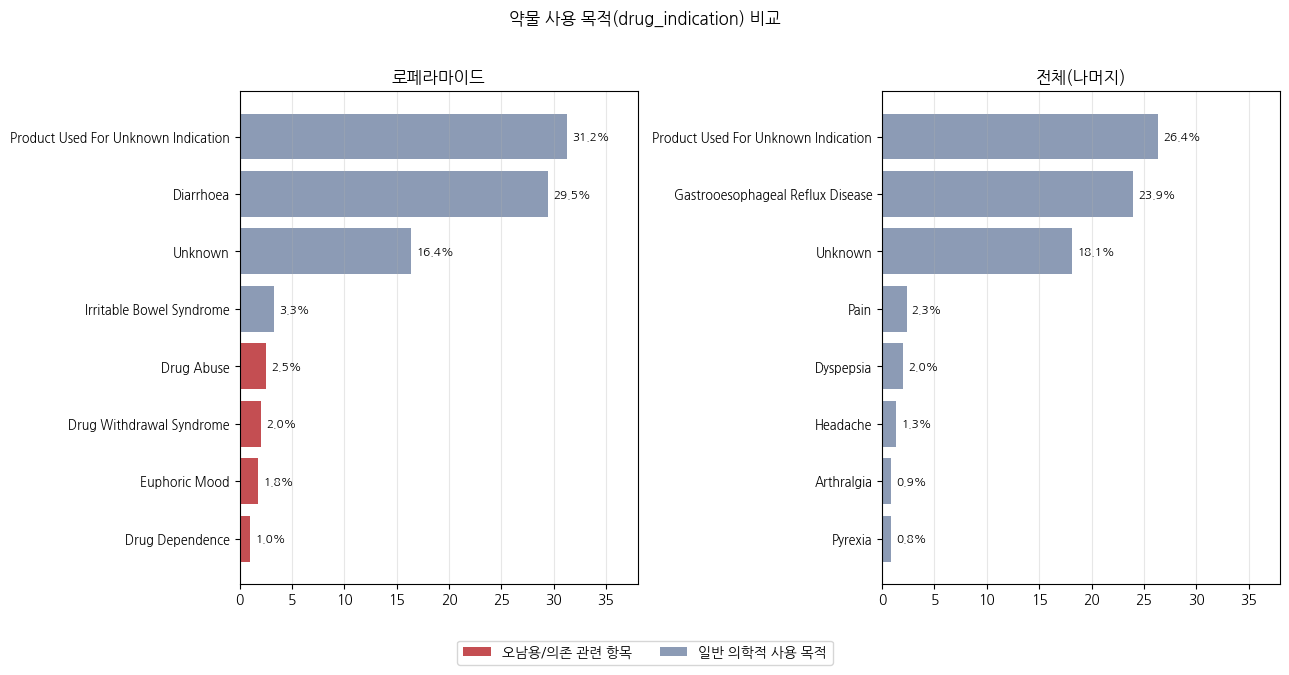

In [11]:
# 약물 사용 목적(drug_indication) 비교
lop_top = df[df['group']=='로페라마이드']['drug_indication'].value_counts(normalize=True).head(8) * 100
whole_top = df[df['group']=='전체(나머지)']['drug_indication'].value_counts(normalize=True).head(8) * 100
abuse_related = {'Drug Abuse', 'Drug Withdrawal Syndrome', 'Euphoric Mood', 'Drug Dependence'}

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True)
for ax, data, title in zip(axes, [lop_top, whole_top], ['로페라마이드', '전체(나머지)']):
    labels = data.index[::-1]
    vals = data.values[::-1]
    colors = ['#C44E52' if lbl in abuse_related else '#8C9BB5' for lbl in labels]
    ax.barh(range(len(labels)), vals, color=colors)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
    for yi, v in zip(range(len(labels)), vals):
        ax.text(v + 0.5, yi, f'{v:.1f}%', va='center', fontsize=8.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 38)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('약물 사용 목적(drug_indication) 비교', y=1.02)
legend_elems = [Patch(facecolor='#C44E52', label='오남용/의존 관련 항목'),
                Patch(facecolor='#8C9BB5', label='일반 의학적 사용 목적')]
fig.legend(handles=legend_elems, loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()